In [3]:
# Magic formulae so that changes in the .py files are loaded in here
%load_ext autoreload
%autoreload 2
###
    
import numpy as np
import matplotlib.pyplot as plt
import matplotlib 
from tqdm.notebook import tqdm
import copy

import pandas as pd
import xarray as xr

import torch.nn as nn
import torch.optim as optim
import random
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
import sklearn


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import os

# def seed_everything(seed=42):
#     random.seed(seed)
#     os.environ['PYTHONHASHSEED'] = str(seed)
#     np.random.seed(seed)
#     torch.manual_seed(seed)
#     torch.cuda.manual_seed(seed)
#     torch.cuda.manual_seed_all(seed) # for multi-GPU
#     torch.backends.cudnn.deterministic = True
#     torch.backends.cudnn.benchmark = False

# seed_everything(42)

def reset_seeds(seed=1):
    # Ensure reproducibility
    # https://docs.pytorch.org/docs/stable/notes/randomness.html
    torch.manual_seed(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    random.seed(seed)
    np.random.seed(seed)
# torch.manual_seed(3)
reset_seeds(1)

In [6]:
ds = xr.open_dataset('data_input/Cyclostationary_LIM_ORAS5_XRO10_GlobColour_PP_RECCAP2_all_regions_valid_zero30_1998_2025.nc')
ds

<xarray.Dataset> Size: 942kB
Dimensions:                                (region: 21, month: 12,
                                            state_to: 11, state_from: 11,
                                            state: 11, time: 336, poly_coeff: 2)
Coordinates:
  * region                                 (region) int16 42B 1 2 3 ... 27 28 29
  * month                                  (month) int16 24B 1 2 3 ... 10 11 12
  * state_to                               (state_to) <U5 220B 'PP' ... 'SASD'
  * state_from                             (state_from) <U5 220B 'PP' ... 'SASD'
  * state                                  (state) <U5 220B 'PP' ... 'SASD'
  * time                                   (time) datetime64[ns] 3kB 1998-01-...
  * poly_coeff                             (poly_coeff) int64 16B 0 1
Data variables: (12/24)
    G                                      (region, month, state_to, state_from) float32 122kB ...
    C0                                     (region, month, state_to, state_from) float32 122kB ...
    C1                                     (region, month, state_to, state_from) float32 122kB ...
    Q                                      (region, month, state_to, state_from) float32 122kB ...
    n_samples                              (region, month) int16 504B ...
    fit_mean_x                             (region, month, state) float32 11kB ...
    ...                                     ...
    original_region_id                     (region) int16 42B ...
    n_total_cells_original_mask            (region) int32 84B ...
    n_valid_cells_threshold_mask           (region) int32 84B ...
    valid_fraction_percent_threshold_mask  (region) float32 84B ...
    n_cells_used_for_regional_mean         (region) int32 84B ...
    area_weight_used_for_regional_mean     (region) float64 168B ...
Attributes: (12/15)
    title:             Regional cyclostationary LIM using ORAS5 XRO inputs an...
    description:       For each retained RECCAP2 all-region mask region, a cy...
    xro_file:          /nird/datalake/NS11071K/users/yongyub/Observation/ORAS...
    xro_variable:      xro_input_standardized
    pp_file:           /nird/datalake/NS11071K/users/yongyub/Observation/Glob...
    pp_variable:       PP
    ...                ...
    ridge_alpha:       0.001
    min_samples:       12
    state_order:       PP, TENSO, WWV, NPMM, SPMM, IOB, IOD, SIOD, TNA, ATL3,...
    period:            1998-01-01 to 2025-12-31
    created_by:        custom Python/xarray script
    date_created:      2026-07-10

In [7]:
ds.state_vector

<xarray.DataArray 'state_vector' (region: 21, time: 336, state: 11)> Size: 310kB
[77616 values with dtype=float32]
Coordinates:
  * region   (region) int16 42B 1 2 3 4 5 6 7 8 9 ... 13 14 15 16 18 19 27 28 29
  * time     (time) datetime64[ns] 3kB 1998-01-15 1998-02-15 ... 2025-12-15
  * state    (state) <U5 220B 'PP' 'TENSO' 'WWV' 'NPMM' ... 'TNA' 'ATL3' 'SASD'
Attributes:
    long_name:    Standardized state vector for regional cyclostationary LIM
    description:  For each retained RECCAP2 all-region mask region, the state...
    units:        standard deviation

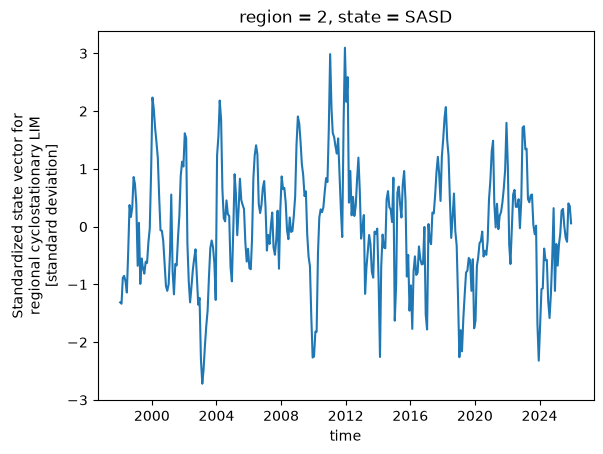

In [33]:
ds.state_vector.sel(region=2).isel(state=10).plot()

In [9]:
# ============================================================
# Settings
# ============================================================

LOOKBACK = 12          # use past 12 months
MAX_LEAD = 24          # forecast up to 24 months
HIDDEN_SIZE = 32
N_LAYERS = 1

n_epochs = 300
batch_size = 64
learning_rate = 1e-3

SKILL_THRESHOLD = 0.5
RUNNING_MEAN_WINDOW = 3   # set 1 if you want raw monthly skill

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)

device: mps


In [35]:
# ============================================================
# Data
# ============================================================

da = ds["state_vector"].transpose("region", "time", "state").astype("float32")

regions = da.region.values
times = da.time.values
state_names = da.state.values.tolist()

print("regions:", regions)
print("states:", state_names)

pp_index = state_names.index("PP")
n_state = len(state_names)

print("PP index:", pp_index)
print("n_state:", n_state)

# Optional safety check
if not np.isfinite(da.values).all():
    raise ValueError("state_vector contains NaN or inf.")

regions: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 18 19 27 28 29]
states: ['PP', 'TENSO', 'WWV', 'NPMM', 'SPMM', 'IOB', 'IOD', 'SIOD', 'TNA', 'ATL3', 'SASD']
PP index: 0
n_state: 11


In [36]:
def make_supervised_data(values, lookback=12):
    """
    values: numpy array of shape [time, state]

    Returns
    -------
    X: [sample, lookback, state]
    y: [sample, state]
    """
    X = []
    y = []

    n_time = values.shape[0]

    for t in range(lookback, n_time):
        X.append(values[t-lookback:t, :])
        y.append(values[t, :])

    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)

    return X, y

class SimpleLSTM(nn.Module):
    def __init__(self, n_state, hidden_size=32, n_layers=1):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=n_state,
            hidden_size=hidden_size,
            num_layers=n_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, n_state)

    def forward(self, x):
        # x: [batch, lookback, state]
        out, _ = self.lstm(x)
        out = out[:, -1, :]     # last hidden state
        out = self.fc(out)      # [batch, state]
        return out

def train_one_region_lstm(
    values,
    lookback=12,
    hidden_size=32,
    n_layers=1,
    n_epochs=300,
    batch_size=64,
    learning_rate=1e-3,
):
    """
    values: [time, state] for one region
    """

    X_np, y_np = make_supervised_data(values, lookback=lookback)

    X = torch.tensor(X_np, dtype=torch.float32).to(device)
    y = torch.tensor(y_np, dtype=torch.float32).to(device)

    model = SimpleLSTM(
        n_state=values.shape[1],
        hidden_size=hidden_size,
        n_layers=n_layers,
    ).to(device)

    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    best_loss_value = np.inf
    best_weights = copy.deepcopy(model.state_dict())
    loss_history = []

    n_samples = X.shape[0]

    for epoch in range(n_epochs):
        model.train()

        # shuffle samples each epoch
        perm = np.random.permutation(n_samples)
        X_shuffled = X[perm]
        y_shuffled = y[perm]

        for start in range(0, n_samples, batch_size):
            X_batch = X_shuffled[start:start+batch_size]
            y_batch = y_shuffled[start:start+batch_size]

            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            loss.backward()
            optimizer.step()

        # evaluate full training loss
        model.eval()
        with torch.no_grad():
            train_pred = model(X)
            train_loss = loss_fn(train_pred, y).item()

        loss_history.append(train_loss)

        if train_loss < best_loss_value:
            best_loss_value = train_loss
            best_weights = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_weights)
    model = model.eval()

    return model, loss_history, best_loss_value

def recursive_forecast(
    model,
    values,
    lookback=12,
    max_lead=24,
):
    """
    Recursive forecast for one region.

    Parameters
    ----------
    model : trained model
    values : [time, state]
    lookback : int
    max_lead : int

    Returns
    -------
    forecast : [n_init, max_lead, state]
    observation : [n_init, max_lead, state]
    init_times : datetime array of initialization times
    """

    n_time, n_state = values.shape

    forecast_list = []
    observation_list = []
    init_times = []

    model.eval()

    with torch.no_grad():
        # initialization month is t
        # we forecast t+1 ... t+max_lead
        for init_idx in range(lookback - 1, n_time - max_lead):
            window = values[init_idx - lookback + 1:init_idx + 1, :].copy()

            region_forecast = []

            for lead in range(max_lead):
                x = torch.tensor(window[None, :, :], dtype=torch.float32).to(device)
                next_state = model(x).detach().cpu().numpy()[0]   # [state]

                region_forecast.append(next_state)

                # recursive update
                window = np.concatenate([window[1:], next_state[None, :]], axis=0)

            region_forecast = np.asarray(region_forecast, dtype=np.float32)
            region_obs = values[init_idx + 1:init_idx + max_lead + 1, :]

            forecast_list.append(region_forecast)
            observation_list.append(region_obs)
            init_times.append(times[init_idx])

    forecast = np.asarray(forecast_list, dtype=np.float32)
    observation = np.asarray(observation_list, dtype=np.float32)
    init_times = np.asarray(init_times)

    return forecast, observation, init_times

def running_mean_over_lead(arr, window=3):
    """
    arr: [n_init, lead, state]

    returns:
        same shape, but first window-1 leads are NaN
    """
    if window == 1:
        return arr.copy()

    out = np.full(arr.shape, np.nan, dtype=np.float32)

    for lead_idx in range(window - 1, arr.shape[1]):
        out[:, lead_idx, :] = np.mean(
            arr[:, lead_idx - window + 1:lead_idx + 1, :],
            axis=1
        )

    return out

In [37]:
def correlation_skill_by_lead(forecast, observation, variable_index):
    """
    forecast, observation: [n_init, lead, state]

    returns
    -------
    skill: [lead]
    """
    n_lead = forecast.shape[1]
    skill = np.full(n_lead, np.nan, dtype=np.float32)

    for lead_idx in range(n_lead):
        f = forecast[:, lead_idx, variable_index]
        o = observation[:, lead_idx, variable_index]

        valid = np.isfinite(f) & np.isfinite(o)

        if valid.sum() < 3:
            continue

        if np.std(f[valid]) == 0 or np.std(o[valid]) == 0:
            continue

        skill[lead_idx] = np.corrcoef(f[valid], o[valid])[0, 1]

    return skill

def latest_skillful_lead(skill, threshold=0.5):
    """
    skill: [lead]

    returns:
        0 if no skillful lead exists,
        else latest lead month (1-based)
    """
    idx = np.where(skill >= threshold)[0]

    if len(idx) == 0:
        return 0
    else:
        return int(idx[-1] + 1)

In [38]:
from tqdm import tqdm
reset_seeds(1)

all_skill = np.full(
    (len(regions), MAX_LEAD),
    np.nan,
    dtype=np.float32,
)

all_latest_lead = np.zeros(
    len(regions),
    dtype=np.int16,
)

all_best_loss = np.full(
    len(regions),
    np.nan,
    dtype=np.float32,
)

all_loss_history = {}

# Save forecast trajectories
all_forecast_pp = {}
all_observation_pp = {}
all_init_times = {}


for i, region in enumerate(tqdm(regions)):

    values = (
        da.sel(region=region)
        .values
        .astype(np.float32)
    )

    model, loss_history, best_loss_value = train_one_region_lstm(
        values=values,
        lookback=LOOKBACK,
        hidden_size=HIDDEN_SIZE,
        n_layers=N_LAYERS,
        n_epochs=n_epochs,
        batch_size=batch_size,
        learning_rate=learning_rate,
    )

    forecast, observation, init_times = recursive_forecast(
        model=model,
        values=values,
        lookback=LOOKBACK,
        max_lead=MAX_LEAD,
    )

    # Save raw monthly trajectories
    all_forecast_pp[int(region)] = (
        forecast[:, :, pp_index].copy()
    )

    all_observation_pp[int(region)] = (
        observation[:, :, pp_index].copy()
    )

    all_init_times[int(region)] = (
        init_times.copy()
    )

    # Skill calculation using running means
    forecast_smoothed = running_mean_over_lead(
        forecast,
        window=RUNNING_MEAN_WINDOW,
    )

    observation_smoothed = running_mean_over_lead(
        observation,
        window=RUNNING_MEAN_WINDOW,
    )

    skill = correlation_skill_by_lead(
        forecast=forecast_smoothed,
        observation=observation_smoothed,
        variable_index=pp_index,
    )

    all_skill[i, :] = skill

    all_latest_lead[i] = latest_skillful_lead(
        skill,
        threshold=SKILL_THRESHOLD,
    )

    all_best_loss[i] = best_loss_value
    all_loss_history[int(region)] = loss_history

100%|██████████████████████████████████████████████████████████████████████████████████████████| 21/21 [01:58<00:00,  5.63s/it]


In [39]:
skill_da = xr.DataArray(
    all_skill,
    dims=("region", "lead"),
    coords={
        "region": regions,
        "lead": np.arange(1, MAX_LEAD + 1),
    },
    name="PP_correlation_skill",
    attrs={
        "description": "In-sample recursive LSTM PP forecast skill",
        "lookback": LOOKBACK,
        "max_lead": MAX_LEAD,
        "running_mean_window": RUNNING_MEAN_WINDOW,
        "threshold": SKILL_THRESHOLD,
    },
)

latest_lead_da = xr.DataArray(
    all_latest_lead,
    dims=("region",),
    coords={"region": regions},
    name="PP_latest_skillful_lead",
    attrs={
        "description": "Latest lead month with correlation skill >= threshold",
        "threshold": SKILL_THRESHOLD,
    },
)

best_loss_da = xr.DataArray(
    all_best_loss,
    dims=("region",),
    coords={"region": regions},
    name="best_training_loss",
)

skill_ds = xr.Dataset({
    "PP_correlation_skill": skill_da,
    "PP_latest_skillful_lead": latest_lead_da,
    "best_training_loss": best_loss_da,
})

skill_ds

<xarray.Dataset> Size: 2kB
Dimensions:                  (region: 21, lead: 24)
Coordinates:
  * region                   (region) int16 42B 1 2 3 4 5 6 ... 18 19 27 28 29
  * lead                     (lead) int64 192B 1 2 3 4 5 6 ... 19 20 21 22 23 24
Data variables:
    PP_correlation_skill     (region, lead) float32 2kB nan nan ... -0.009511
    PP_latest_skillful_lead  (region) int16 42B 18 20 18 21 19 ... 17 14 18 14
    best_training_loss       (region) float32 84B 0.1263 0.1137 ... 0.1067

In [40]:
from pathlib import Path
from matplotlib.colors import BoundaryNorm, ListedColormap

import cartopy.crs as ccrs
import cartopy.feature as cfeature


# ============================================================
# Settings
# ============================================================

THRESHOLD = 0.5

# Excluded only from figures
EXCLUDE_REGIONS = [6, 18, 19, 29]

# Map settings
CENTRAL_LONGITUDE = 210
PLOT_STRIDE = 4

# Leads above this value use the same final map color
DISPLAY_MAX_LEAD = 15


# Local path to the valid-zero30 mask file
VALID_MASK_FILE = Path(
    "data_input/"
    "RECCAP2_all_regions_valid_mask_zero30_on_PPgrid.nc"
)


# Optional:
# A previous LIM/XRO skill file containing region_name, basin,
# and original_region_id.
#
# Leave as None if these variables already exist in ds.
REGION_INFO_FILE = None

# Example:
# REGION_INFO_FILE = Path(
#     "/replace/with/local/path/"
#     "XRO_PP_forecast_skill_24month_"
#     "3month_running_mean_corr_threshold05_"
#     "RECCAP2_all_regions_valid_zero30.nc"
# )


BASIN_SHORT = {
    "Pacific Ocean": "PO",
    "Indian Ocean": "IO",
    "Atlantic Ocean": "AO",
    "Southern Ocean": "SO",
    "Arctic Ocean": "ArO",
}

BASIN_ORDER = [
    "Pacific Ocean",
    "Indian Ocean",
    "Atlantic Ocean",
    "Southern Ocean",
    "Arctic Ocean",
]


# ============================================================
# Verification description
# ============================================================

if RUNNING_MEAN_WINDOW == 1:
    verification_label = "monthly verification"
else:
    verification_label = (
        f"{RUNNING_MEAN_WINDOW}-month running-mean verification"
    )


# ============================================================
# Region metadata dataset
# ============================================================

close_region_info = False

if (
    "region_name" in ds
    or "basin" in ds
    or "original_region_id" in ds
):
    ds_region_info = ds

elif REGION_INFO_FILE is not None:
    REGION_INFO_FILE = Path(REGION_INFO_FILE)

    if not REGION_INFO_FILE.exists():
        raise FileNotFoundError(
            f"Region-information file not found:\n"
            f"{REGION_INFO_FILE}"
        )

    ds_region_info = xr.open_dataset(REGION_INFO_FILE)
    close_region_info = True

else:
    ds_region_info = None


# ============================================================
# Helper functions: region metadata
# ============================================================

def decode_str(value):
    """
    Decode a netCDF string or byte-string scalar.
    """
    if isinstance(value, bytes):
        return value.decode("utf-8")

    arr = np.asarray(value)

    if arr.shape == ():
        item = arr.item()

        if isinstance(item, bytes):
            return item.decode("utf-8")

        return str(item)

    return str(value)


def get_region_label(reg, short=True):
    """
    Region label for heatmap and regional panels.
    """
    reg = int(reg)

    if (
        ds_region_info is not None
        and "region_name" in ds_region_info
    ):
        try:
            name = decode_str(
                ds_region_info["region_name"]
                .sel(region=reg)
                .values
            )
        except Exception:
            name = f"region {reg}"
    else:
        name = f"region {reg}"

    if (
        ds_region_info is not None
        and "basin" in ds_region_info
    ):
        try:
            basin = decode_str(
                ds_region_info["basin"]
                .sel(region=reg)
                .values
            )
        except Exception:
            basin = ""
    else:
        basin = ""

    if (
        ds_region_info is not None
        and "original_region_id" in ds_region_info
    ):
        try:
            original_id = int(
                ds_region_info["original_region_id"]
                .sel(region=reg)
                .values
            )
        except Exception:
            original_id = -999
    else:
        original_id = -999

    if short:
        return f"R{reg}. {name}"

    if basin != "" and original_id > 0:
        return (
            f"R{reg}. {basin}:{original_id} {name}"
        )

    return f"R{reg}. {name}"


def get_basin_name(reg):
    """
    Convert the basin metadata to one of five standard names.
    """
    reg = int(reg)

    if (
        ds_region_info is None
        or "basin" not in ds_region_info
    ):
        return "Unknown"

    try:
        raw = decode_str(
            ds_region_info["basin"]
            .sel(region=reg)
            .values
        ).strip()
    except Exception:
        return "Unknown"

    name = raw.lower()

    if "pacific" in name:
        return "Pacific Ocean"

    if "indian" in name:
        return "Indian Ocean"

    if "atlantic" in name:
        return "Atlantic Ocean"

    if "southern" in name:
        return "Southern Ocean"

    if "arctic" in name:
        return "Arctic Ocean"

    return raw


# ============================================================
# Helper functions: map
# ============================================================

def lon_to_180(lon):
    """
    Convert longitude from 0–360 to -180–180.
    """
    return ((lon + 180.0) % 360.0) - 180.0


def weighted_centroid(lon, lat, region_mask):
    """
    Area-weighted centroid using cosine-latitude weights.

    Circular longitude averaging handles dateline-crossing regions.
    """
    lon2d, lat2d = np.meshgrid(lon, lat)

    weights = np.cos(np.deg2rad(lat2d))
    weights = np.where(region_mask, weights, 0.0)

    weight_sum = np.nansum(weights)

    if weight_sum <= 0:
        return np.nan, np.nan

    lon_rad = np.deg2rad(lon2d)

    x = (
        np.nansum(weights * np.cos(lon_rad))
        / weight_sum
    )

    y = (
        np.nansum(weights * np.sin(lon_rad))
        / weight_sum
    )

    lon_center = (
        np.rad2deg(np.arctan2(y, x))
        % 360.0
    )

    lat_center = (
        np.nansum(weights * lat2d)
        / weight_sum
    )

    return lon_center, lat_center


def add_cyclic_manual(data, lon):
    """
    Add a cyclic longitude column without requiring
    perfectly equally spaced longitude coordinates.
    """
    lon = np.asarray(lon, dtype=np.float64)

    sort_idx = np.argsort(lon)

    lon_sorted = lon[sort_idx]
    data_sorted = data[:, sort_idx]

    dlon = float(
        np.nanmedian(
            np.diff(lon_sorted)
        )
    )

    lon_cyclic = np.concatenate(
        [
            lon_sorted,
            [lon_sorted[-1] + dlon],
        ]
    )

    data_cyclic = np.concatenate(
        [
            data_sorted,
            data_sorted[:, :1],
        ],
        axis=1,
    )

    return data_cyclic, lon_cyclic

In [41]:
# ============================================================
# Prepare LSTM skill
# ============================================================

r_pool = skill_da.transpose(
    "region",
    "lead",
)

leads = (
    r_pool["lead"]
    .values
    .astype(np.int16)
)


# ============================================================
# Latest lead with r >= threshold
# ============================================================

latest_lead_da = xr.where(
    r_pool >= THRESHOLD,
    r_pool["lead"],
    0,
).max(
    dim="lead"
).astype(
    np.int16
)

latest_lead_da.name = "PP_latest_skillful_lead"

latest_lead_da.attrs = {
    "long_name": (
        "Latest recursive LSTM PP forecast lead "
        f"with correlation skill >= {THRESHOLD}"
    ),
    "threshold": THRESHOLD,
    "verification": verification_label,
    "forecast_type": (
        "one-step trained, recursively integrated"
    ),
    "evaluation": "in-sample",
}


# ============================================================
# Exclude selected regions only from figures
# ============================================================

keep_regions = [
    int(reg)
    for reg in r_pool["region"].values
    if int(reg) not in EXCLUDE_REGIONS
]


# ============================================================
# Basin information
# ============================================================

region_basin = {
    int(reg): get_basin_name(reg)
    for reg in keep_regions
}

basin_rank = {
    basin_name: index
    for index, basin_name in enumerate(BASIN_ORDER)
}


# Sort first by ocean basin, then region number
regions = np.array(
    sorted(
        keep_regions,
        key=lambda reg: (
            basin_rank.get(
                region_basin[int(reg)],
                len(BASIN_ORDER),
            ),
            int(reg),
        ),
    ),
    dtype=np.int16,
)


r_plot = r_pool.sel(region=regions)

latest_plot = latest_lead_da.sel(
    region=regions
)

n_region = len(regions)


# ============================================================
# Basin groups for separators and right-side labels
# ============================================================

basin_groups = []

for basin_name in BASIN_ORDER:
    indices = [
        i
        for i, reg in enumerate(regions)
        if region_basin[int(reg)] == basin_name
    ]

    if len(indices) > 0:
        basin_groups.append(
            {
                "name": basin_name,
                "start": min(indices),
                "end": max(indices),
            }
        )


basin_centers = [
    0.5 * (
        group["start"]
        + group["end"]
        + 1
    )
    for group in basin_groups
]

basin_labels = [
    BASIN_SHORT.get(
        group["name"],
        group["name"],
    )
    for group in basin_groups
]


print("Plotted regions:")

for reg in regions:
    reg = int(reg)

    print(
        f"{get_region_label(reg, short=False)}: "
        f"latest={int(latest_plot.sel(region=reg).values)} months"
    )

Plotted regions:
R7. pacific:1 NP SPSS: latest=16 months
R8. pacific:2 NP STSS: latest=18 months
R9. pacific:3 NP STPS: latest=20 months
R10. pacific:4 PEQU-W: latest=22 months
R11. pacific:5 PEQU-E: latest=17 months
R12. pacific:6 SP STPS: latest=15 months
R13. indian:1 Arabian Sea: latest=19 months
R14. indian:2 Bay of Bengal: latest=15 months
R15. indian:3 Equatorial Indian: latest=24 months
R16. indian:4 Southern Indian: latest=15 months
R1. atlantic:1 NA SPSS: latest=18 months
R2. atlantic:2 NA STSS: latest=20 months
R3. atlantic:3 NA STPS: latest=18 months
R4. atlantic:4 AEQU: latest=21 months
R5. atlantic:5 SA STPS: latest=19 months
R27. southern:1 SO STSS: latest=14 months
R28. southern:2 SO SPSS: latest=18 months


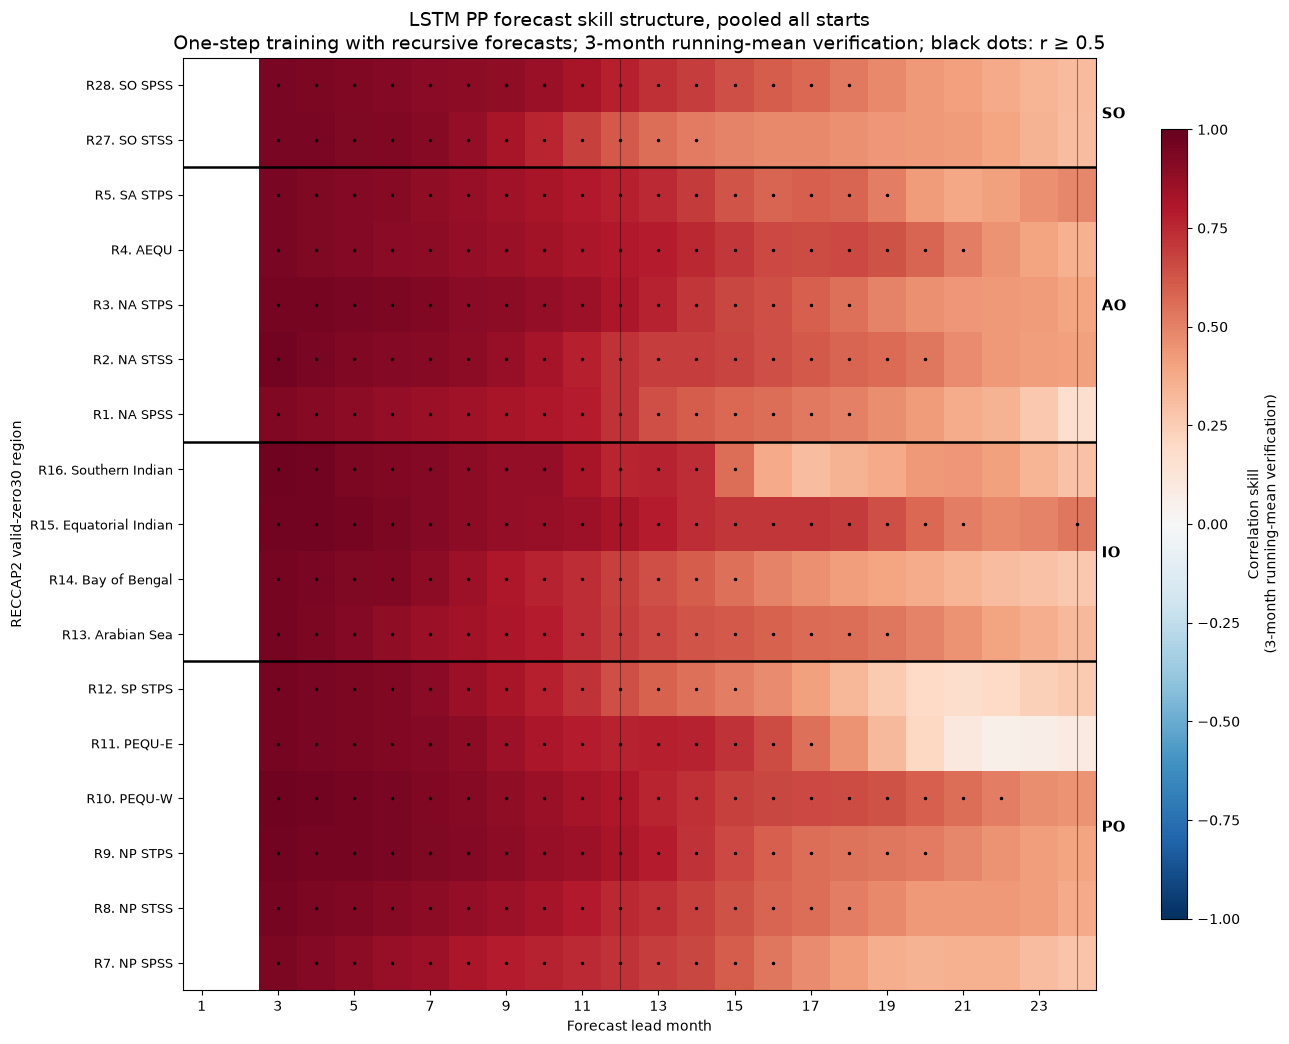

In [42]:
# ============================================================
# Heatmap: region x lead
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        14.5,
        0.48 * n_region + 3.8,
    )
)

y_edges = np.arange(
    n_region + 1
)

x_edges = np.arange(
    leads[0] - 0.5,
    leads[-1] + 1.5,
    1.0,
)


im = ax.pcolormesh(
    x_edges,
    y_edges,
    r_plot.values,
    vmin=-1,
    vmax=1,
    cmap="RdBu_r",
    shading="auto",
)


# ============================================================
# Mark cells with r >= threshold
# ============================================================

correlation_values = r_plot.values

for region_index, reg in enumerate(regions):
    y = region_index + 0.5

    for lead_index, lead in enumerate(leads):
        value = correlation_values[
            region_index,
            lead_index,
        ]

        if (
            np.isfinite(value)
            and value >= THRESHOLD
        ):
            ax.plot(
                lead,
                y,
                "k.",
                markersize=3,
            )


# ============================================================
# Thick separators between basins
# ============================================================

for group in basin_groups[:-1]:
    boundary = group["end"] + 1

    ax.axhline(
        boundary,
        color="k",
        lw=1.8,
    )


# ============================================================
# Basin abbreviations on right
# ============================================================

if len(basin_groups) > 0:
    ax_basin = ax.twinx()

    ax_basin.set_ylim(
        0,
        n_region,
    )

    ax_basin.set_yticks(
        basin_centers
    )

    ax_basin.set_yticklabels(
        basin_labels,
        fontsize=11,
        fontweight="bold",
    )

    ax_basin.tick_params(
        axis="y",
        which="both",
        length=0,
        pad=4,
    )

    ax_basin.set_ylabel("")

    for spine in ax_basin.spines.values():
        spine.set_visible(False)


# ============================================================
# Reference lead lines
# ============================================================

if leads[-1] >= 12:
    ax.axvline(
        12,
        color="k",
        lw=0.8,
        alpha=0.4,
    )

if leads[-1] >= 24:
    ax.axvline(
        24,
        color="k",
        lw=0.8,
        alpha=0.4,
    )


# ============================================================
# Axes
# ============================================================

ax.set_xlim(
    leads[0] - 0.5,
    leads[-1] + 0.5,
)

ax.set_ylim(
    0,
    n_region,
)

ax.set_xlabel(
    "Forecast lead month"
)

ax.set_ylabel(
    "RECCAP2 valid-zero30 region"
)

ax.set_title(
    "LSTM PP forecast skill structure, pooled all starts\n"
    "One-step training with recursive forecasts; "
    f"{verification_label}; black dots: r ≥ {THRESHOLD}",
    fontsize=14,
)

ax.set_xticks(
    np.arange(
        leads[0],
        leads[-1] + 1,
        2,
    )
)

ax.set_yticks(
    np.arange(n_region) + 0.5
)

ax.set_yticklabels(
    [
        get_region_label(
            reg,
            short=True,
        )
        for reg in regions
    ],
    fontsize=9,
)


# ============================================================
# Figure and colorbar positions
# ============================================================

fig.subplots_adjust(
    left=0.20,
    right=0.83,
    top=0.88,
    bottom=0.10,
)

cax = fig.add_axes(
    [0.875, 0.16, 0.018, 0.66]
)

cbar = fig.colorbar(
    im,
    cax=cax,
)

cbar.set_label(
    "Correlation skill\n"
    f"({verification_label})"
)

plt.show()

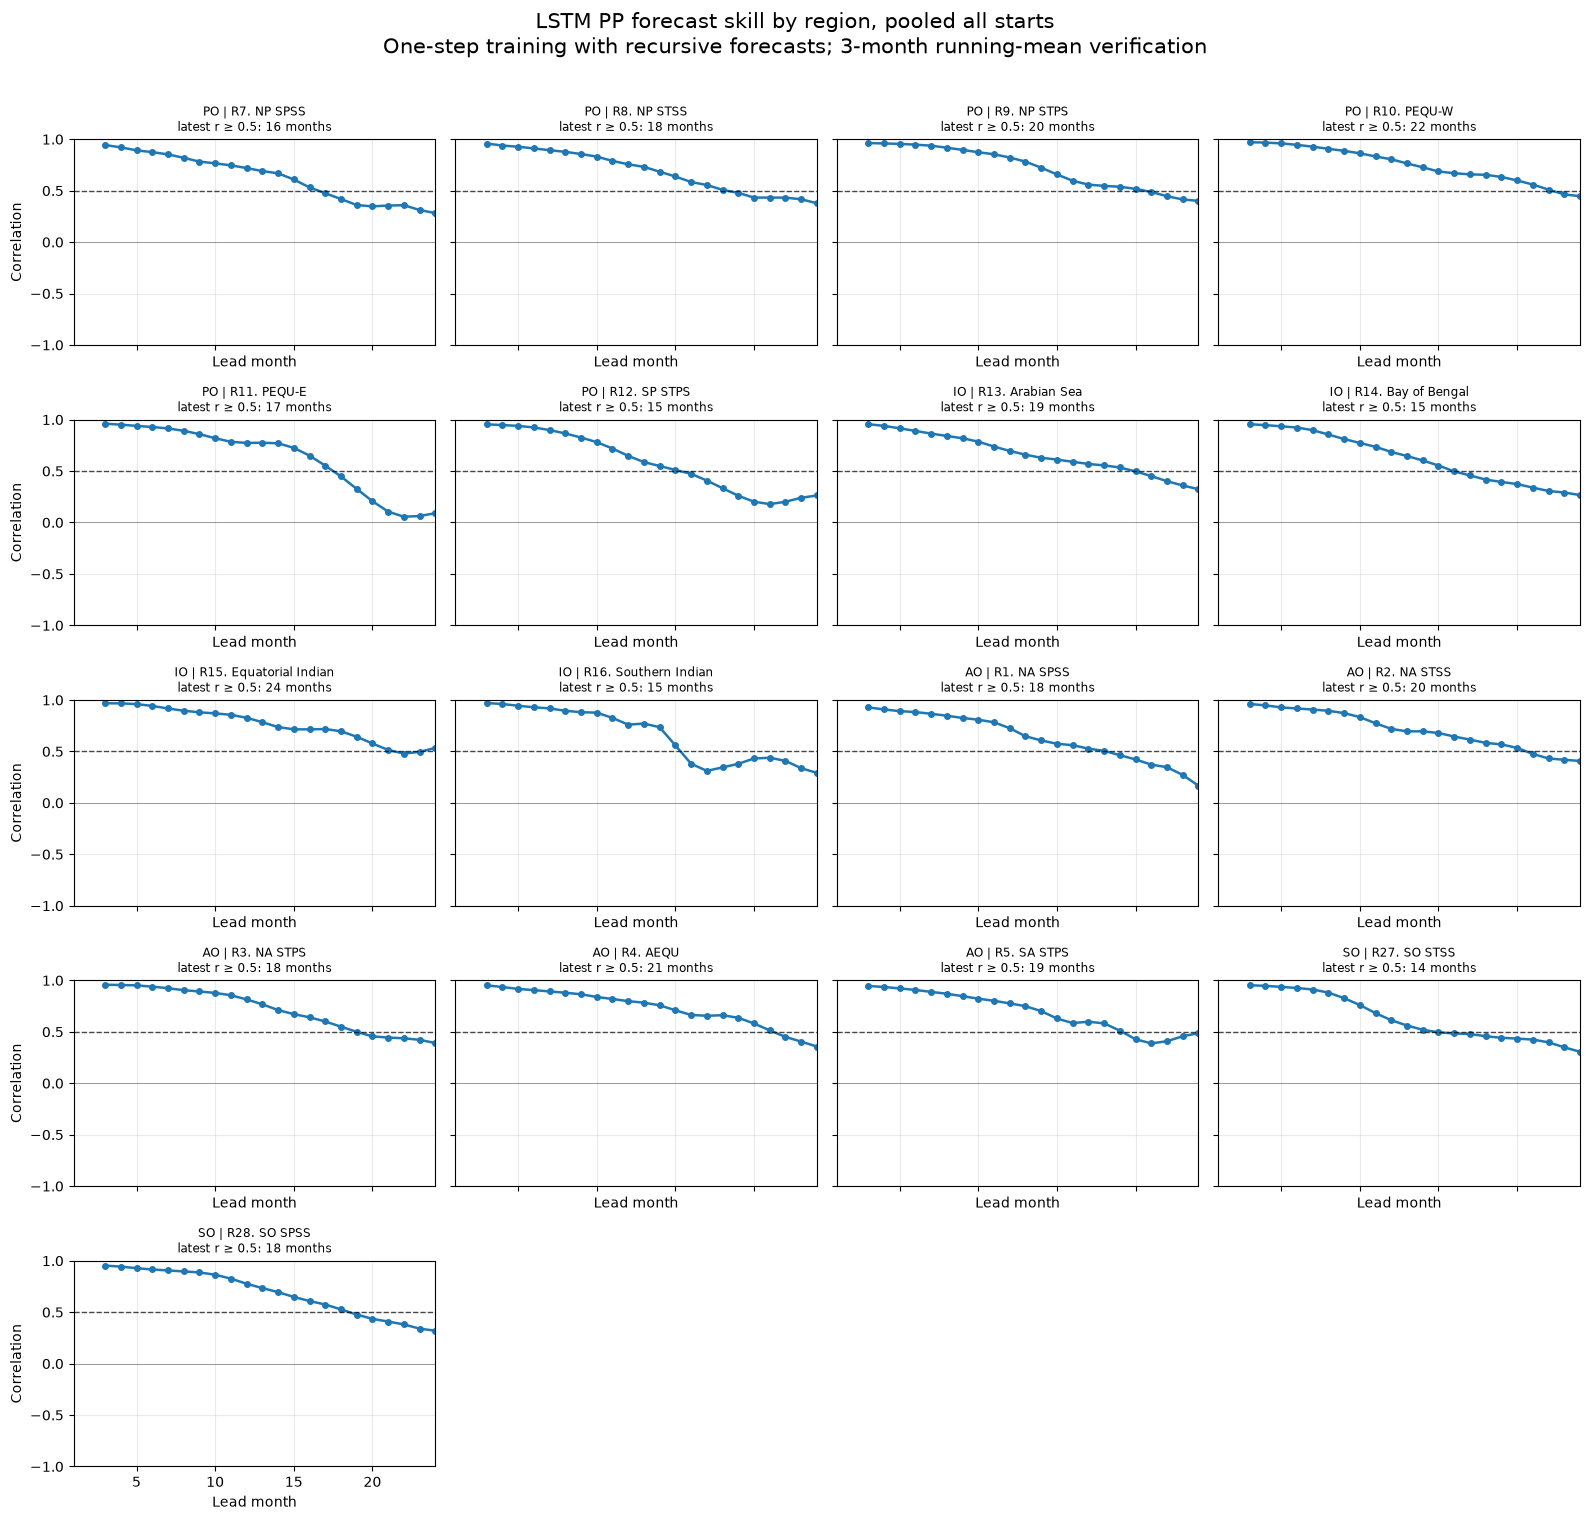

In [43]:
# ============================================================
# Regional line panels
# ============================================================

ncol = 4

nrow = int(
    np.ceil(
        n_region / ncol
    )
)

fig, axes = plt.subplots(
    nrow,
    ncol,
    figsize=(
        16,
        3.0 * nrow,
    ),
    sharex=True,
    sharey=True,
)

axes = np.asarray(
    axes
).ravel()


for ax, reg in zip(
    axes,
    regions,
):
    reg = int(reg)

    region_skill = r_plot.sel(
        region=reg
    )

    basin = region_basin[reg]

    basin_short = BASIN_SHORT.get(
        basin,
        basin,
    )

    region_label = get_region_label(
        reg,
        short=True,
    )

    latest_value = int(
        latest_plot
        .sel(region=reg)
        .values
    )

    ax.plot(
        leads,
        region_skill.values,
        marker="o",
        lw=1.8,
        ms=4,
        label="LSTM",
    )

    ax.axhline(
        THRESHOLD,
        color="k",
        lw=1.0,
        ls="--",
        alpha=0.7,
    )

    ax.axhline(
        0,
        color="k",
        lw=0.6,
        alpha=0.4,
    )

    ax.set_title(
        f"{basin_short} | {region_label}\n"
        f"latest r ≥ {THRESHOLD}: {latest_value} months",
        fontsize=8.5,
    )

    ax.set_xlim(
        leads[0],
        leads[-1],
    )

    ax.set_ylim(
        -1,
        1,
    )

    ax.grid(
        alpha=0.25
    )


# Hide unused axes
for ax in axes[n_region:]:
    ax.axis("off")


# Axis labels
for index, ax in enumerate(
    axes[:n_region]
):
    ax.set_xlabel(
        "Lead month"
    )

    if index % ncol == 0:
        ax.set_ylabel(
            "Correlation"
        )


fig.suptitle(
    "LSTM PP forecast skill by region, pooled all starts\n"
    "One-step training with recursive forecasts; "
    f"{verification_label}",
    fontsize=15,
    y=1.01,
)

plt.tight_layout()
plt.show()

Mapped regions:
[1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 27, 28]

Latest skillful lead:
Region  1: 18 months
Region  2: 20 months
Region  3: 18 months
Region  4: 21 months
Region  5: 19 months
Region  7: 16 months
Region  8: 18 months
Region  9: 20 months
Region 10: 22 months
Region 11: 17 months
Region 12: 15 months
Region 13: 19 months
Region 14: 15 months
Region 15: 24 months
Region 16: 15 months
Region 27: 14 months
Region 28: 18 months


/Users/yongyub.kim/Applications/miniconda3/envs/ml/lib/python3.11/site-packages/shapely/predicates.py:762: RuntimeWarning: invalid value encountered in covers
  return lib.covers(a, b, **kwargs)
/Users/yongyub.kim/Applications/miniconda3/envs/ml/lib/python3.11/site-packages/shapely/predicates.py:806: RuntimeWarning: invalid value encountered in disjoint
  return lib.disjoint(a, b, **kwargs)
/Users/yongyub.kim/Applications/miniconda3/envs/ml/lib/python3.11/site-packages/shapely/predicates.py:762: RuntimeWarning: invalid value encountered in covers
  return lib.covers(a, b, **kwargs)
/Users/yongyub.kim/Applications/miniconda3/envs/ml/lib/python3.11/site-packages/shapely/predicates.py:806: RuntimeWarning: invalid value encountered in disjoint
  return lib.disjoint(a, b, **kwargs)
/Users/yongyub.kim/Applications/miniconda3/envs/ml/lib/python3.11/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/yongyub.kim/Application

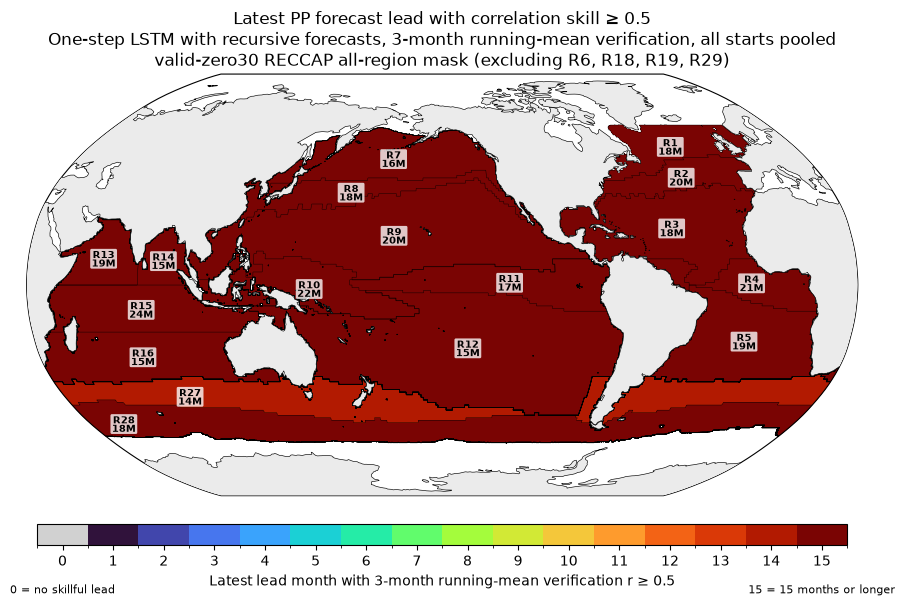

In [44]:
# ============================================================
# Check and open mask file
# ============================================================

if not VALID_MASK_FILE.exists():
    raise FileNotFoundError(
        f"Valid-mask file not found:\n"
        f"{VALID_MASK_FILE}"
    )


ds_mask = xr.open_dataset(
    VALID_MASK_FILE
)


MASK_VARIABLE = "valid_region_mask"

if MASK_VARIABLE not in ds_mask:
    raise KeyError(
        f"{MASK_VARIABLE} not found in:\n"
        f"{VALID_MASK_FILE}"
    )


# Coordinate-name handling
if "latitude" in ds_mask.coords:
    lat_name = "latitude"
elif "lat" in ds_mask.coords:
    lat_name = "lat"
else:
    raise KeyError(
        "No latitude or lat coordinate found."
    )


if "longitude" in ds_mask.coords:
    lon_name = "longitude"
elif "lon" in ds_mask.coords:
    lon_name = "lon"
else:
    raise KeyError(
        "No longitude or lon coordinate found."
    )


mask = (
    ds_mask[MASK_VARIABLE]
    .transpose(
        lat_name,
        lon_name,
    )
)

lat = (
    ds_mask[lat_name]
    .values
    .astype(float)
)

lon = (
    ds_mask[lon_name]
    .values
    .astype(float)
)

mask_values = (
    mask.values
    .astype(np.int16)
)


# ============================================================
# Exclude selected regions only for plotting
# ============================================================

mask_plot_full = mask_values.copy()

for excluded_region in EXCLUDE_REGIONS:
    mask_plot_full[
        mask_plot_full == excluded_region
    ] = 0


mask_region_set = set(
    np.unique(
        mask_plot_full[
            mask_plot_full > 0
        ]
    ).astype(int)
)


regions_to_map = [
    int(reg)
    for reg in latest_lead_da["region"].values
    if (
        int(reg) not in EXCLUDE_REGIONS
        and int(reg) in mask_region_set
    )
]


latest_map_values = (
    latest_lead_da
    .sel(region=regions_to_map)
)


print("Mapped regions:")
print(regions_to_map)

print("\nLatest skillful lead:")

for reg in regions_to_map:
    value = int(
        latest_map_values
        .sel(region=reg)
        .values
    )

    print(
        f"Region {reg:2d}: "
        f"{value:2d} months"
    )


# ============================================================
# Map region values to the PP grid
# ============================================================

lead_map = np.full(
    mask_values.shape,
    np.nan,
    dtype=np.float32,
)


for reg in regions_to_map:
    value = float(
        latest_map_values
        .sel(region=reg)
        .values
    )

    lead_map[
        mask_plot_full == reg
    ] = value


lead_map = np.where(
    mask_plot_full > 0,
    lead_map,
    np.nan,
)


# ============================================================
# Coarsen only for plotting
# ============================================================

lat_plot = lat[
    ::PLOT_STRIDE
]

lon_plot = lon[
    ::PLOT_STRIDE
]

lead_plot = lead_map[
    ::PLOT_STRIDE,
    ::PLOT_STRIDE,
]

mask_plot = mask_plot_full[
    ::PLOT_STRIDE,
    ::PLOT_STRIDE,
].astype(float)


lead_cyclic, lon_cyclic = (
    add_cyclic_manual(
        lead_plot,
        lon_plot,
    )
)

mask_cyclic, _ = (
    add_cyclic_manual(
        mask_plot,
        lon_plot,
    )
)


# ============================================================
# Region boundary levels
# ============================================================

remaining_regions = np.unique(
    mask_plot_full[
        mask_plot_full > 0
    ]
)

if remaining_regions.size == 0:
    raise ValueError(
        "No regions remain after exclusions."
    )


boundary_levels = np.arange(
    0.5,
    int(
        np.nanmax(
            remaining_regions
        )
    ) + 1.5,
    1.0,
)


# ============================================================
# Discrete map color scale
# ============================================================

# Values above DISPLAY_MAX_LEAD share the final color.
# Zero means that no lead reached r >= threshold.
lead_cyclic_display = np.where(
    np.isfinite(lead_cyclic),
    np.minimum(
        lead_cyclic,
        DISPLAY_MAX_LEAD,
    ),
    np.nan,
)


bounds = np.arange(
    -0.5,
    DISPLAY_MAX_LEAD + 1.5,
    1.0,
)


try:
    base_cmap = plt.get_cmap(
        "turbo",
        DISPLAY_MAX_LEAD,
    )
except ValueError:
    base_cmap = plt.get_cmap(
        "plasma",
        DISPLAY_MAX_LEAD,
    )


colors = (
    [(0.82, 0.82, 0.82, 1.0)]
    + [
        base_cmap(i)
        for i in range(
            DISPLAY_MAX_LEAD
        )
    ]
)


map_cmap = ListedColormap(
    colors
)

map_cmap.set_bad(
    (1, 1, 1, 0)
)


map_norm = BoundaryNorm(
    bounds,
    map_cmap.N,
)


# ============================================================
# Plot map
# ============================================================

fig = plt.figure(
    figsize=(13.5, 6.2)
)

ax = plt.axes(
    projection=ccrs.Robinson(
        central_longitude=CENTRAL_LONGITUDE
    )
)


im = ax.pcolormesh(
    lon_cyclic,
    lat_plot,
    lead_cyclic_display,
    cmap=map_cmap,
    norm=map_norm,
    shading="auto",
    transform=ccrs.PlateCarree(),
)


# Region boundaries
ax.contour(
    lon_cyclic,
    lat_plot,
    mask_cyclic,
    levels=boundary_levels,
    colors="k",
    linewidths=0.30,
    transform=ccrs.PlateCarree(),
)


# Land and coastline
ax.add_feature(
    cfeature.LAND,
    facecolor="0.92",
    edgecolor="none",
    zorder=3,
)

ax.coastlines(
    linewidth=0.45,
    zorder=4,
)

ax.set_global()


# ============================================================
# Title
# ============================================================

ax.set_title(
    "Latest PP forecast lead with correlation skill ≥ 0.5\n"
    "One-step LSTM with recursive forecasts, "
    f"{verification_label}, all starts pooled\n"
    "valid-zero30 RECCAP all-region mask "
    "(excluding R6, R18, R19, R29)",
    fontsize=12.5,
)


# ============================================================
# Region labels
# ============================================================

for reg in regions_to_map:
    region_mask = (
        mask_plot_full == reg
    )

    if not np.any(region_mask):
        continue

    lon_center, lat_center = (
        weighted_centroid(
            lon,
            lat,
            region_mask,
        )
    )

    if not (
        np.isfinite(lon_center)
        and np.isfinite(lat_center)
    ):
        continue

    value = int(
        latest_map_values
        .sel(region=reg)
        .values
    )

    label_text = (
        f"R{reg}\n"
        f"{value}M"
    )

    ax.text(
        lon_to_180(
            lon_center
        ),
        lat_center,
        label_text,
        transform=ccrs.PlateCarree(),
        ha="center",
        va="center",
        fontsize=7.2,
        fontweight="bold",
        linespacing=0.85,
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.78,
            boxstyle="round,pad=0.14",
        ),
        zorder=5,
    )


# ============================================================
# Colorbar
# ============================================================

fig.subplots_adjust(
    left=0.03,
    right=0.97,
    top=0.84,
    bottom=0.16,
)

cax = fig.add_axes(
    [0.20, 0.08, 0.60, 0.035]
)

cbar = fig.colorbar(
    im,
    cax=cax,
    orientation="horizontal",
    ticks=np.arange(
        0,
        DISPLAY_MAX_LEAD + 1,
        1,
    ),
    boundaries=bounds,
)

cbar.set_label(
    "Latest lead month with "
    f"{verification_label} r ≥ {THRESHOLD}"
)

cbar.ax.text(
    0,
    -1.8,
    "0 = no skillful lead",
    ha="center",
    va="top",
    transform=(
        cbar.ax
        .get_xaxis_transform()
    ),
    fontsize=8,
)

cbar.ax.text(
    DISPLAY_MAX_LEAD,
    -1.8,
    (
        f"{DISPLAY_MAX_LEAD} = "
        f"{DISPLAY_MAX_LEAD} months or longer"
    ),
    ha="center",
    va="top",
    transform=(
        cbar.ax
        .get_xaxis_transform()
    ),
    fontsize=8,
)

plt.show()


# ============================================================
# Close files opened in these plotting cells
# ============================================================

ds_mask.close()

if close_region_info:
    ds_region_info.close()

In [60]:
def plot_spaghetti_region(
    region,
    every=3,
    start_date=None,
    end_date=None,
    figsize=(14, 5),
):
    region = int(region)

    forecast_pp = all_forecast_pp[region]
    init_times = all_init_times[region]

    observed = da.sel(
        region=region,
        state="PP",
    )

    observed_times = pd.to_datetime(
        observed.time.values
    )

    observed_pp = observed.values

    fig, ax = plt.subplots(figsize=figsize)

    for i in range(0, len(init_times), every):

        init_time = pd.Timestamp(init_times[i])

        # init month, lead 1, ..., lead 24
        trajectory_times = [
            init_time + pd.DateOffset(months=lead)
            for lead in range(MAX_LEAD + 1)
        ]

        initial_pp = float(
            da.sel(
                region=region,
                state="PP",
                time=init_times[i],
            ).values
        )

        # initial observed value + lead 1–24 forecasts
        trajectory_values = np.concatenate(
            [
                [initial_pp],
                forecast_pp[i, :],
            ]
        )

        ax.plot(
            trajectory_times,
            trajectory_values,
            color="tab:red",
            linewidth=1.0,
            alpha=0.45,
            zorder=3,
        )

    ax.plot(
        observed_times,
        observed_pp,
        color="k",
        linewidth=1.4,
        alpha=0.75,
        label="Observed PP",
        zorder=2,
    )

    ax.axhline(
        0,
        color="k",
        linewidth=0.6,
        alpha=0.4,
    )

    if start_date is not None:
        ax.set_xlim(left=pd.Timestamp(start_date))

    if end_date is not None:
        ax.set_xlim(right=pd.Timestamp(end_date))

    ax.set_title(
        f"Region {region}: recursive LSTM forecasts"
    )

    ax.set_ylabel("Standardized PP anomaly")
    ax.set_xlabel("Target time")
    ax.grid(alpha=0.2)
    ax.legend()

    plt.tight_layout()
    plt.show()

In [61]:
def plot_all_region_spaghetti(
    regions_to_plot=None,
    every=6,
    ncol=3,
):
    if regions_to_plot is None:
        regions_to_plot = [
            int(reg)
            for reg in regions
            if int(reg) in all_forecast_pp
        ]

    n_region = len(
        regions_to_plot
    )

    nrow = int(
        np.ceil(
            n_region / ncol
        )
    )

    fig, axes = plt.subplots(
        nrow,
        ncol,
        figsize=(
            17,
            3.2 * nrow,
        ),
        sharex=True,
        sharey=True,
    )

    axes = np.asarray(
        axes
    ).ravel()

    observed_times = pd.to_datetime(
        da.time.values
    )

    for ax, region in zip(
        axes,
        regions_to_plot,
    ):
        region = int(region)

        forecast_pp = (
            all_forecast_pp[region]
        )

        init_times = (
            all_init_times[region]
        )

        observed_pp = (
            da.sel(
                region=region,
                state="PP",
            )
            .values
        )

        # Forecast trajectories
        for i in range(
            0,
            len(init_times),
            every,
        ):
            init_time = pd.Timestamp(
                init_times[i]
            )

            target_times = [
                init_time
                + pd.DateOffset(
                    months=lead
                )
                for lead in range(
                    1,
                    MAX_LEAD + 1,
                )
            ]

            initial_pp = float(
                da.sel(
                    region=region,
                    state="PP",
                    time=init_times[i],
                ).values
            )

            trajectory_values = np.concatenate(
                [
                    [initial_pp],
                    forecast_pp[i, :],
                ]
            )

            ax.plot(
                [init_time] + target_times,
                trajectory_values,
                linewidth=0.55,
                alpha=0.15,
            )

        # Observed time series
        ax.plot(
            observed_times,
            observed_pp,
            color="k",
            linewidth=1.5,
            zorder=10,
        )

        ax.axhline(
            0,
            color="k",
            linewidth=0.5,
            alpha=0.4,
        )

        ax.set_title(
            f"Region {region}",
            fontsize=10,
        )

        ax.grid(
            alpha=0.15
        )

    # Hide unused axes
    for ax in axes[n_region:]:
        ax.axis("off")

    for i, ax in enumerate(
        axes[:n_region]
    ):
        if i % ncol == 0:
            ax.set_ylabel(
                "Standardized PP"
            )

    fig.suptitle(
        "Recursive LSTM PP forecast spaghetti plots\n"
        f"{MAX_LEAD}-month trajectories; "
        f"one trajectory every {every} initialization months",
        fontsize=15,
        y=1.01,
    )

    plt.tight_layout()
    plt.show()

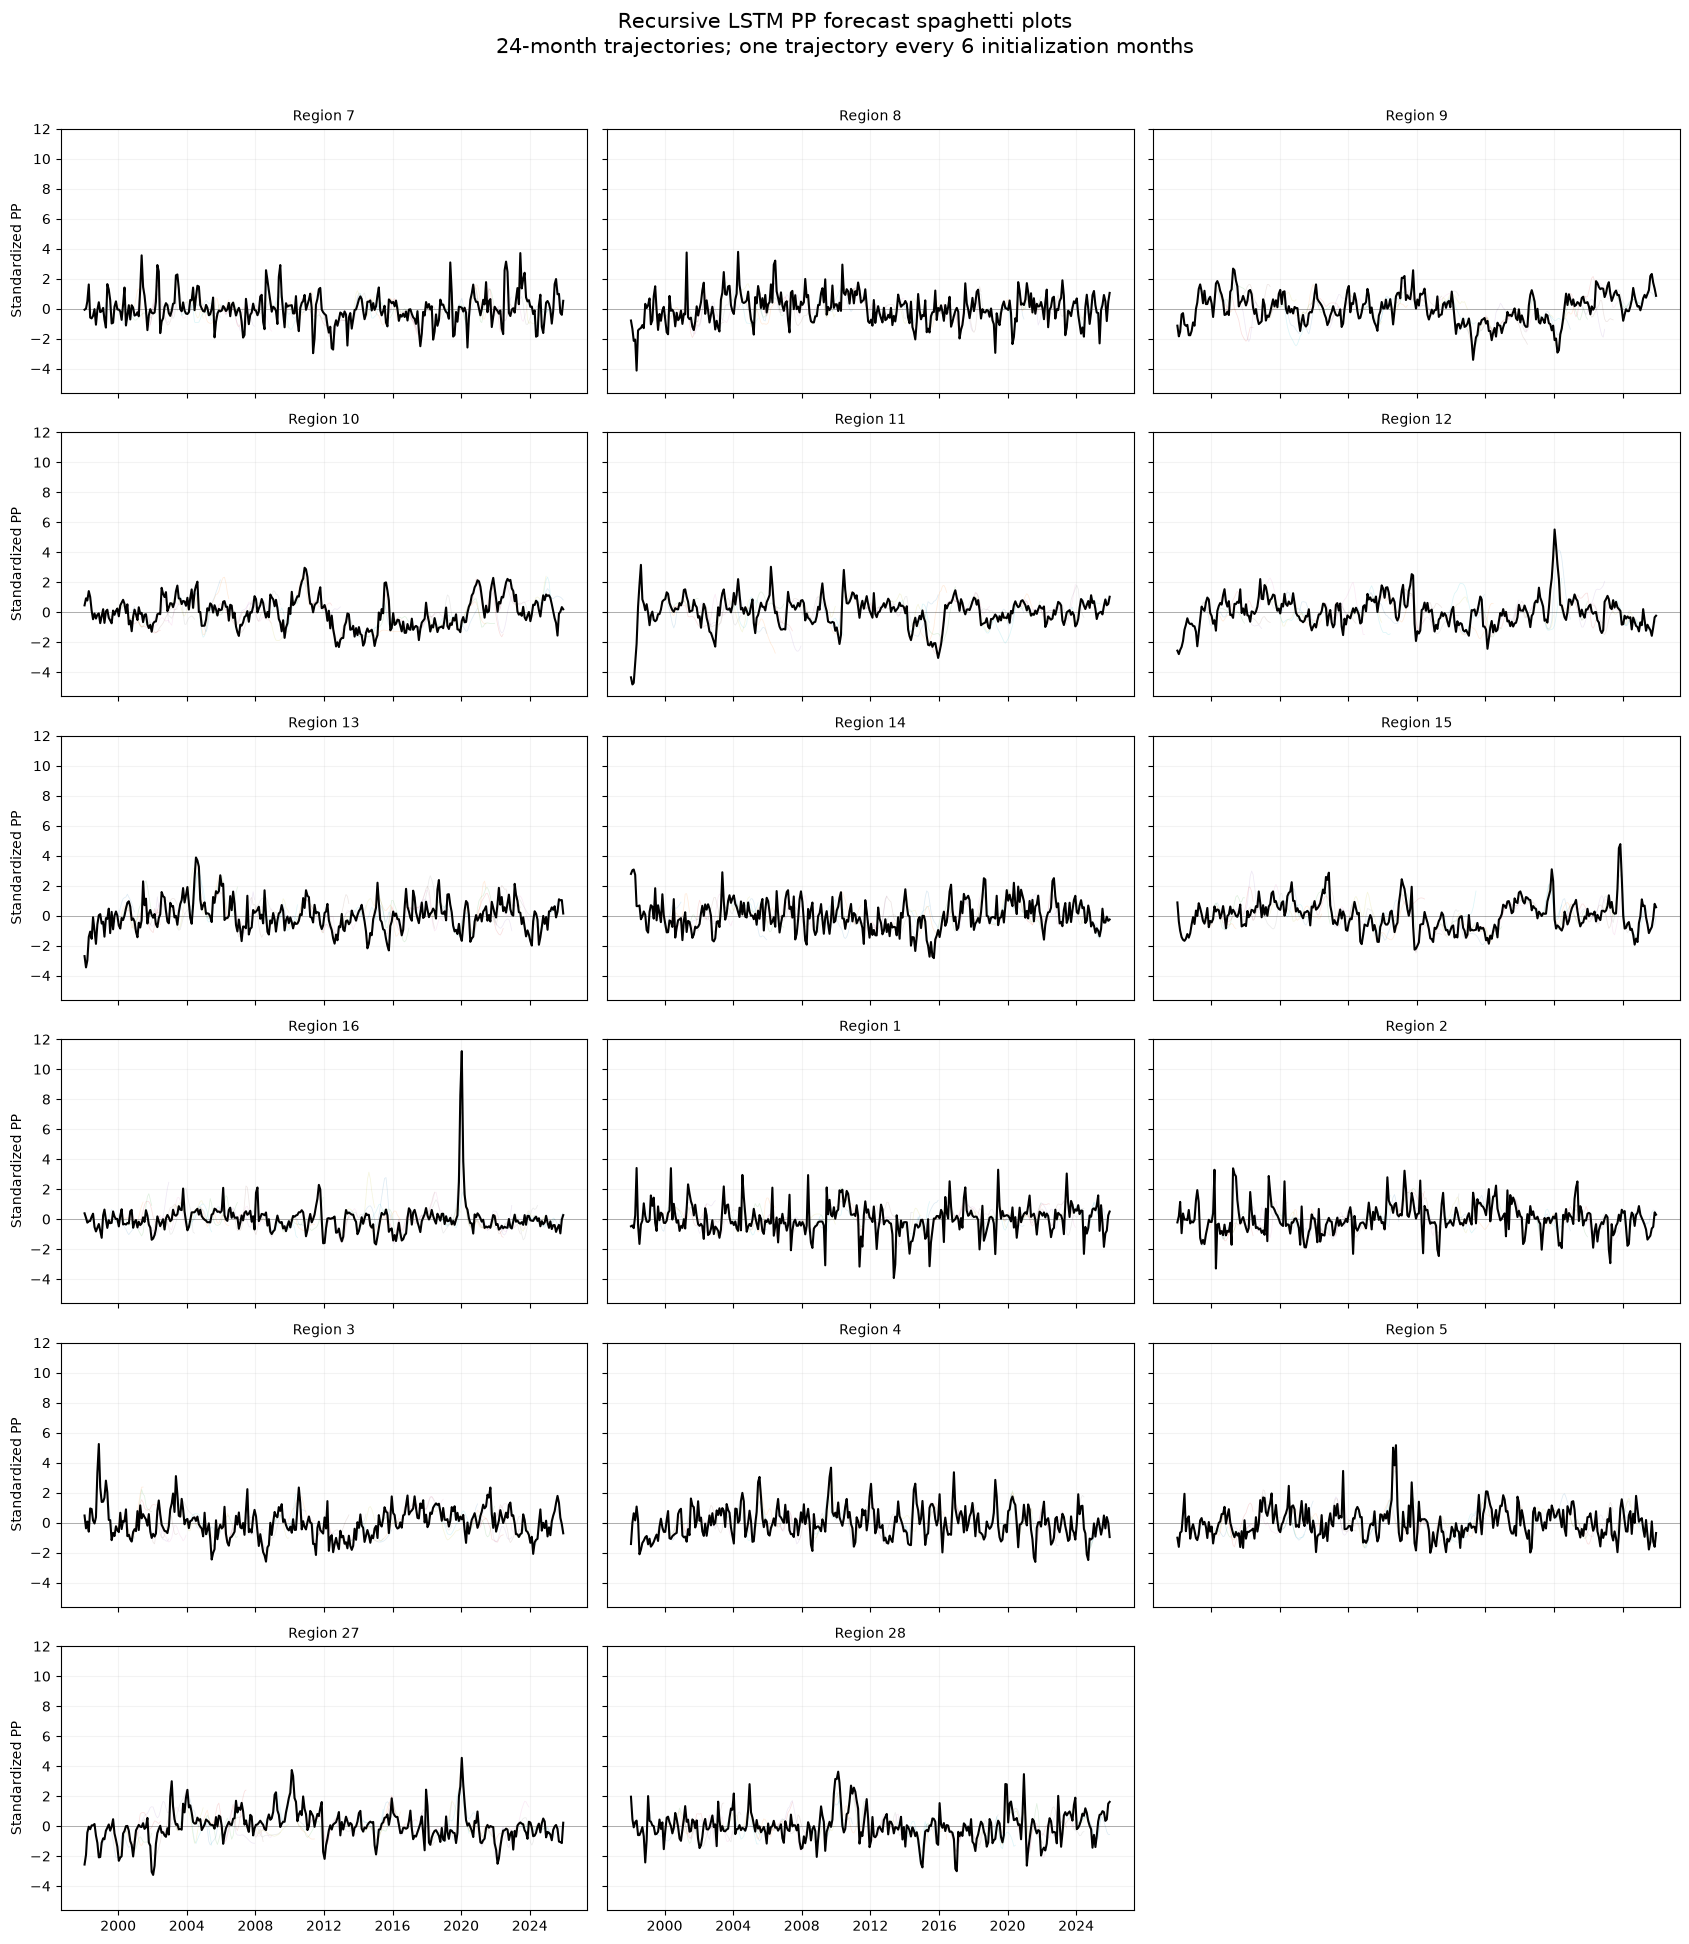

In [62]:
regions_spaghetti = [
    int(reg)
    for reg in regions
    if int(reg) not in [6, 18, 19, 29]
]

plot_all_region_spaghetti(
    regions_to_plot=regions_spaghetti,
    every=6,
    ncol=3,
)

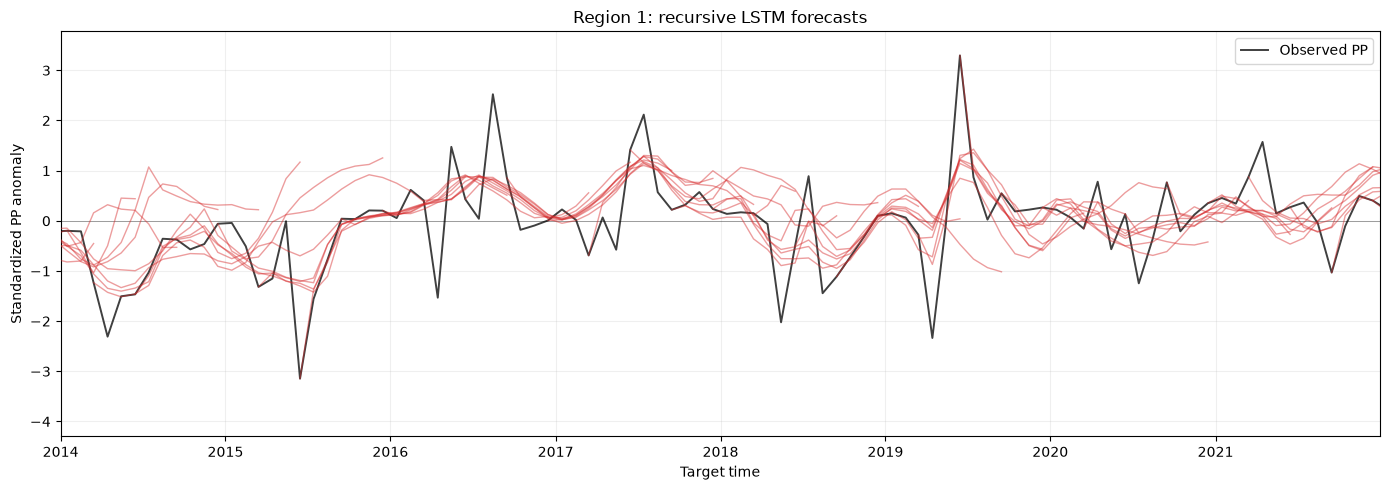

In [63]:
plot_spaghetti_region(
    region=1,
    every=3,
    start_date="2014-01-01",
    end_date="2021-12-31",
)

In [57]:
print("Original:", da.region.values)
print("Current regions:", regions)

print(
    "Missing:",
    sorted(
        set(da.region.values.astype(int))
        - set(np.asarray(regions).astype(int))
    )
)

Original: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 18 19 27 28 29]
Current regions: [ 7  8  9 10 11 12 13 14 15 16  1  2  3  4  5 27 28]
Missing: [np.int64(6), np.int64(18), np.int64(19), np.int64(29)]


In [64]:
def plot_spaghetti_region_3month(
    region,
    every=3,
    start_date=None,
    end_date=None,
    window=3,
    figsize=(14, 5),
):
    region = int(region)

    # Raw monthly forecasts: [initialization, lead]
    forecast_pp = all_forecast_pp[region]
    init_times = all_init_times[region]

    # ========================================================
    # 3-month trailing mean along forecast lead
    # ========================================================

    forecast_smoothed = np.full_like(
        forecast_pp,
        np.nan,
        dtype=np.float32,
    )

    for lead_idx in range(
        window - 1,
        forecast_pp.shape[1],
    ):
        forecast_smoothed[:, lead_idx] = np.mean(
            forecast_pp[
                :,
                lead_idx - window + 1:
                lead_idx + 1,
            ],
            axis=1,
        )

    # ========================================================
    # Observed PP and corresponding 3-month trailing mean
    # ========================================================

    observed = da.sel(
        region=region,
        state="PP",
    )

    observed_smoothed = observed.rolling(
        time=window,
        min_periods=window,
    ).mean()

    observed_times = pd.to_datetime(
        observed_smoothed.time.values
    )

    observed_values = (
        observed_smoothed.values
    )

    # ========================================================
    # Plot
    # ========================================================

    fig, ax = plt.subplots(
        figsize=figsize
    )

    for i in range(
        0,
        len(init_times),
        every,
    ):
        init_time = pd.Timestamp(
            init_times[i]
        )

        # Forecast lead 1 ... MAX_LEAD
        target_times = [
            init_time
            + pd.DateOffset(months=lead)
            for lead in range(
                1,
                MAX_LEAD + 1,
            )
        ]

        ax.plot(
            target_times,
            forecast_smoothed[i, :],
            color="tab:red",
            linewidth=1.0,
            alpha=0.45,
            zorder=3,
        )

    # Observed 3-month running mean
    ax.plot(
        observed_times,
        observed_values,
        color="k",
        linewidth=1.7,
        alpha=0.85,
        label="Observed PP, 3-month mean",
        zorder=4,
    )

    ax.axhline(
        0,
        color="k",
        linewidth=0.6,
        alpha=0.4,
    )

    if start_date is not None:
        ax.set_xlim(
            left=pd.Timestamp(start_date)
        )

    if end_date is not None:
        ax.set_xlim(
            right=pd.Timestamp(end_date)
        )

    ax.set_title(
        f"Region {region}: recursive LSTM forecasts\n"
        f"{window}-month trailing-mean PP"
    )

    ax.set_ylabel(
        "Standardized PP anomaly"
    )

    ax.set_xlabel(
        "Target time"
    )

    ax.grid(
        alpha=0.2
    )

    ax.legend()

    plt.tight_layout()
    plt.show()

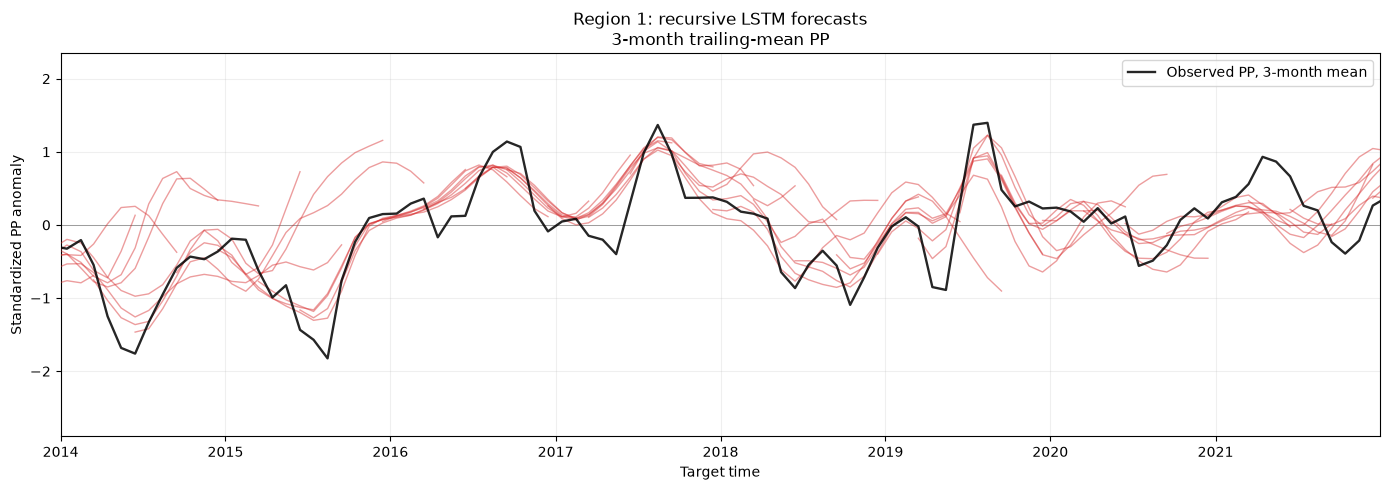

In [65]:
plot_spaghetti_region_3month(
    region=1,
    every=3,
    start_date="2014-01-01",
    end_date="2021-12-31",
)